# **Araç ve Yaya Algılama**

####**Bu derste şunları öğreneceğiz:**
1. Yayaları tespit etmek için bir Haarcascade sınıflandırıcı kullanma
2. Haarcascade sınıflandırıcılarımızı videolar üzerinde kullanma
3. Araçları veya arabaları tespit etmek için bir Haarcascade sınıflandırıcı kullanma


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()


#### **Videomuzdan Tek Bir Kare Üzerinde Test**

In [4]:
# Video yakalama nesnemizi oluşturalım
cap = cv2.VideoCapture('../files/videos/deneme10.mp4')

# Gövde sınıflandırıcımızı yükleyelim
body_classifier = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_fullbody.xml')

# İlk çerçeveyi oku
ret, frame = cap.read()

# Başarıyla okunursa Ret True olur
if ret:

  #Daha hızlı işlem için görüntümüzü gri tonlayın
  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

  # Çerçeveyi yaya sınıflandırıcımıza aktaralım
  bodies = body_classifier.detectMultiScale(gray, 1.2, 3)

  # Tanımlanan tüm yayalar için sınırlayıcı kutuları çıkaralım
  for (x,y,w,h) in bodies:
      cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

# Video yakalama nesnemizi oluşturalım
cap = cv2.VideoCapture('../files/videos/deneme10.mp4')

# Video dosyasının başarıyla açılıp açılmadığını kontrol edelim
if not cap.isOpened():
    print("Error: Video dosyası açılamadı.")
    print("Lütfen dosya yolunu kontrol edin:", '../files/videos/deneme10.mp4')
else:
    # Gövde sınıflandırıcımızı yükleyelim
    body_classifier = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_fullbody.xml')

    # İlk çerçeveyi oku
    ret, frame = cap.read()

    # Başarıyla okunursa Ret True olur
    if ret:
        #Daha hızlı işlem için görüntümüzü gri tonlayın
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Çerçeveyi yaya sınıflandırıcımıza aktaralım
        bodies = body_classifier.detectMultiScale(gray, 1.2, 3)

        # Tanımlanan tüm yayalar için sınırlayıcı kutuları çıkaralım
        for (x,y,w,h) in bodies:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

        # Görüntüyü göster
        imshow("Pedestrian Detector", frame, 6)
    else:
        print("Error: Video frame okunamadı.")

# Yakalanan Videoyu bırakalım
cap.release()

Error: Video dosyası açılamadı.
Lütfen dosya yolunu kontrol edin: ../files/videos/deneme10.mp4


#### **15 saniyelik klibimiz üzerinde test ediyoruz**

**NOT**: Çalışması yaklaşık 1 dakika sürer.

Çıktıyı bir AVI dosyası olarak kaydetmek için cv2.VideoWriter kullanıyoruz.

```cv2.VideoWriter(video_output.avi, cv2.VideoWriter_fourcc('M','J','P','G'), FPS, (width, height))```

Formatlar şunlar olabilir:
- 'M','J','P','G' or MJPG
- MP4V
- X264
- avc1
- XVID



In [10]:
# Video yakalama nesnemizi oluşturalım
cap = cv2.VideoCapture('../files/videos/deneme10.mp4')

# Çerçevenin yüksekliğini ve genişliğini alalım 
w = int(cap.get(3))
h = int(cap.get(4))

# Codec'i tanımlayalım ve VideoWriter nesnesini oluşturalım. Çıktı 'deneme10.avi' dosyasında saklanır.
out = cv2.VideoWriter('deneme10.avi', cv2.VideoWriter_fourcc('M','J','P','G'), 30, (w, h))

body_detector = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_fullbody.xml')

# Video başarıyla yüklendiğinde döngü ile tüm çarçeveleri okuyalım
while(True):

  ret, frame = cap.read()
  if ret:

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Çerçeveyi yaya sınıflandırıcımıza aktarın
    bodies = body_detector.detectMultiScale(gray, 1.2, 3)

    # Tanımlanan tüm yayalar için sınırlayıcı kutuları çıkaralım
    for (x,y,w,h) in bodies:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

    # Kareyi 'walking_output.avi' dosyasına yazın
    out.write(frame)
  else:
      break
# NOT: Çalışması yaklaşık 1 dakika sürer.
# walking_output.avi dosyası oluşacaktır.
cap.release()
out.release()

In [11]:
#Kaydedilen videoyu oynatmak için önce .mp4 e çevirelim. Ardından oynatalım
cap = cv2.VideoCapture('walking_output.avi')
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter('deneme10.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 30, (w, h))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)

cap.release()
out.release()

from IPython.display import Video, display
display(Video("deneme10.mp4", embed=True))

#### **Tek Görüntü Üzerinde Araç Algılama**

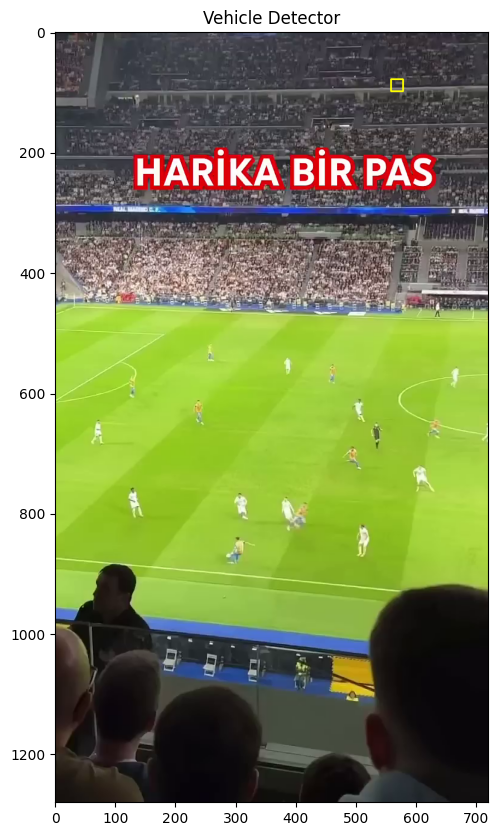

In [12]:
# Video yakalama nesnemizi oluşturalım
cap = cv2.VideoCapture('../files/videos/deneme10.mp4')

# Araç sınıflandırıcımızı yükleyelim
vehicle_detector = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_car.xml')

# İlk çerçeveyi oku
ret, frame = cap.read()

# Başarıyla okunursa Ret True olur
if ret:

  #Daha hızlı işlem için görüntümüzü gri tonlayalım
  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

  # Çerçeveyi yaya sınıflandırıcımıza aktaralım
  vehicles = vehicle_detector.detectMultiScale(gray, 1.4, 2)

  # Tanımlanan tüm gövdeler için sınırlayıcı kutuları çıkaralım
  for (x,y,w,h) in vehicles:
      cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

# Video nesnemizi bırakalım
cap.release()
imshow("Vehicle Detector", frame)

#### **15 saniyelik video üzerinde test ediyoruz**

In [19]:
# Video yakalama nesnemizi oluşturalım
cap = cv2.VideoCapture('../files/videos/cars.mp4')

# Çerçevenin yüksekliğini ve genişliğini alın 
w = int(cap.get(3))
h = int(cap.get(4))

# Codec'i tanımlayın ve VideoWriter nesnesini oluşturun Çıktı 'cars_output.avi' dosyasında saklanır.
out = cv2.VideoWriter('cars_output.avi', cv2.VideoWriter_fourcc('M','J','P','G'), 30, (w, h))

vehicle_detector = cv2.CascadeClassifier('../files/Haarcascades/haarcascade_car.xml')

# Video başarıyla yüklendiğinde döngü ile çerçeveleri okuyalım
while(True):

  ret, frame = cap.read()
  if ret:

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Çerçeveyi yaya sınıflandırıcımıza aktaralım
    vehicles = vehicle_detector.detectMultiScale(gray, 1.2, 3)

    # Tanımlanan tüm yayalar için sınırlayıcı kutuları çıkarın
    for (x,y,w,h) in vehicles:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 255), 2)

    # Çerçeveyi 'cars_output.avi' dosyasına yazın
    out.write(frame)
  else:
      break

cap.release()
out.release()

In [20]:
#Kaydedlime videoyu oynatmak için önce .mp4 e çevirelim. Ardından oynatalım
cap = cv2.VideoCapture('deneme10.mp4')
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
out = cv2.VideoWriter('deneme10.mp4', cv2.VideoWriter_fourcc(*'mp4v'), 30, (w, h))

while True:
    ret, frame = cap.read()
    if not ret:
        break
    out.write(frame)

cap.release()
out.release()

from IPython.display import Video, display
display(Video("deneme10.mp4", embed=True))